# TT-07 — Gradient Boosting: Dự đoán thu nhập
Adult Census Income — hỗ trợ chấm điểm hồ sơ vay tiêu dùng.

**Bẫy dữ liệu:** `' ?'` có dấu cách trước, chuỗi có khoảng trắng thừa, `education`/`education-num` trùng lặp, `fnlwgt` không liên quan cá nhân.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier, AdaBoostClassifier)
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, accuracy_score
import joblib

COLS = ['age','workclass','fnlwgt','education','education-num','marital-status',
        'occupation','relationship','race','sex','capital-gain','capital-loss',
        'hours-per-week','native-country','income']

## 1. Đọc & làm sạch dữ liệu

In [2]:
from pathlib import Path

def find_data_dir():
    candidates = [Path('data'), Path('../data'), Path('../../data')]
    for c in candidates:
        if (c / 'adult.data').exists():
            return c
    raise FileNotFoundError(
        "Không tìm thấy adult.data. Đặt file trong thư mục 'data/' "
        "cùng cấp với 'notebooks/', hoặc sửa đường dẫn thủ công.")

DATA_DIR = find_data_dir()
print('Đang dùng thư mục dữ liệu:', DATA_DIR.resolve())

def load_clean(path, skiprows=0):
    df = pd.read_csv(path, header=None, names=COLS, skiprows=skiprows,
                      skipinitialspace=True, na_values='?')
    for c in df.select_dtypes(include='object').columns:
        df[c] = df[c].str.strip()
    df['income'] = df['income'].str.rstrip('.')
    df['income'] = (df['income'] == '>50K').astype(int)
    df = df.drop(columns=['fnlwgt', 'education'])  # bẫy 3 & 4
    return df

train_df = load_clean(DATA_DIR / 'adult.data')
test_df = load_clean(DATA_DIR / 'adult.test', skiprows=1)
print('Train:', train_df.shape, '| Test:', test_df.shape)
print('Tỉ lệ >50K (train):', round(train_df['income'].mean(), 3))
train_df.isna().sum()[train_df.isna().sum() > 0]

Đang dùng thư mục dữ liệu: /home/claude/TT-07-GradientBoosting/data


Train: (32561, 13) | Test: (16281, 13)
Tỉ lệ >50K (train): 0.241


/tmp/ipykernel_473/714956950.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns:
/tmp/ipykernel_473/714956950.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for deta

workclass         1836
occupation        1843
native-country     583
dtype: int64

In [3]:
y_train, y_test = train_df.pop('income'), test_df.pop('income')
X_train, X_test = train_df, test_df
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()
cat_cols, num_cols

/tmp/ipykernel_473/160578488.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns.tolist()


(['workclass',
  'marital-status',
  'occupation',
  'relationship',
  'race',
  'sex',
  'native-country'],
 ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week'])

## 2. EDA nhanh

In [4]:
eda = X_train.assign(income=y_train)
display(eda.groupby('education-num')['income'].mean().round(3))
display(eda.groupby('marital-status')['income'].mean().round(3))
print('capital-gain = 0:', f"{(X_train['capital-gain']==0).mean():.1%}")

education-num
1     0.000
2     0.036
3     0.048
4     0.062
5     0.053
6     0.066
7     0.051
8     0.076
9     0.160
10    0.190
11    0.261
12    0.248
13    0.415
14    0.557
15    0.734
16    0.741
Name: income, dtype: float64

marital-status
Divorced                 0.104
Married-AF-spouse        0.435
Married-civ-spouse       0.447
Married-spouse-absent    0.081
Never-married            0.046
Separated                0.064
Widowed                  0.086
Name: income, dtype: float64

capital-gain = 0: 91.7%


## 3. Pipeline tiền xử lý
Boosting **không cần scale** số, chỉ OneHot cho biến phân loại.

In [5]:
pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols),
])
def make_pipe(model):
    return Pipeline([('pre', pre), ('clf', model)])

## 4. Baseline: Dummy & Decision Tree

In [6]:
results = {}
for name, model in [('Dummy', DummyClassifier(strategy='most_frequent')),
                     ('DecisionTree', DecisionTreeClassifier(max_depth=6, random_state=42))]:
    pipe = make_pipe(model).fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    results[name] = {'pr_auc': average_precision_score(y_test, proba),
                      'roc_auc': roc_auc_score(y_test, proba)}
    print(f"{name}: PR-AUC={results[name]['pr_auc']:.3f}, ROC-AUC={results[name]['roc_auc']:.3f}")

Dummy: PR-AUC=0.236, ROC-AUC=0.500


DecisionTree: PR-AUC=0.723, ROC-AUC=0.895


## 5. Gradient Boosting
`learning_rate` nhỏ + `n_estimators` lớn + cây nông (`max_depth=3`, weak learner).

In [7]:
gb = GradientBoostingClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=3,
    subsample=0.8, validation_fraction=0.1, n_iter_no_change=20,
    random_state=42,
)
gb_pipe = make_pipe(gb)
t0 = time.time()
gb_pipe.fit(X_train, y_train)
gb_time = time.time() - t0
proba = gb_pipe.predict_proba(X_test)[:, 1]
results['GradientBoosting'] = {'pr_auc': average_precision_score(y_test, proba),
                                'roc_auc': roc_auc_score(y_test, proba)}
print(f"ROC-AUC={results['GradientBoosting']['roc_auc']:.3f}, "
      f"PR-AUC={results['GradientBoosting']['pr_auc']:.3f}, train_time={gb_time:.1f}s")

ROC-AUC=0.925, PR-AUC=0.820, train_time=9.4s


## 6. Train/Validation loss theo số cây → xác định điểm overfit

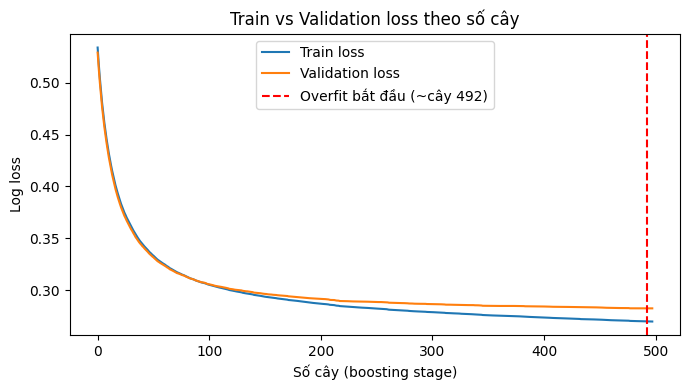

Điểm bắt đầu overfit ~ cây thứ 492 / 498


In [8]:
Xtr_t = gb_pipe.named_steps['pre'].transform(X_train)
Xte_t = gb_pipe.named_steps['pre'].transform(X_test)
fitted_gb = gb_pipe.named_steps['clf']
train_loss = [log_loss(y_train, p) for p in fitted_gb.staged_predict_proba(Xtr_t)]
test_loss = [log_loss(y_test, p) for p in fitted_gb.staged_predict_proba(Xte_t)]
best_iter = int(np.argmin(test_loss))

plt.figure(figsize=(7, 4))
plt.plot(train_loss, label='Train loss')
plt.plot(test_loss, label='Validation loss')
plt.axvline(best_iter, color='red', ls='--', label=f'Overfit bắt đầu (~cây {best_iter})')
plt.xlabel('Số cây (boosting stage)'); plt.ylabel('Log loss')
plt.title('Train vs Validation loss theo số cây'); plt.legend()
plt.tight_layout(); plt.savefig(str(DATA_DIR.parent / 'reports' / 'loss_theo_so_cay.png'), dpi=120); plt.show()
print(f'Điểm bắt đầu overfit ~ cây thứ {best_iter} / {len(test_loss)}')

## 7. Dò lưới learning_rate × n_estimators (chứng minh quan hệ nghịch)

In [9]:
lrs = [0.01, 0.05, 0.3]
n_ests = [100, 300, 500]
grid = np.zeros((len(lrs), len(n_ests)))
for i, lr in enumerate(lrs):
    for j, ne in enumerate(n_ests):
        m = make_pipe(GradientBoostingClassifier(
            n_estimators=ne, learning_rate=lr, max_depth=3, subsample=0.8, random_state=42))
        m.fit(X_train, y_train)
        p = m.predict_proba(X_test)[:, 1]
        grid[i, j] = roc_auc_score(y_test, p)

grid_df = pd.DataFrame(grid, index=lrs, columns=n_ests)
grid_df.index.name = 'learning_rate'; grid_df.columns.name = 'n_estimators'
display(grid_df.round(4))

n_estimators,100,300,500
learning_rate,,,
0.01,0.8943,0.9103,0.9152
0.05,0.9157,0.9235,0.9252
0.30,0.9242,0.9238,0.9218


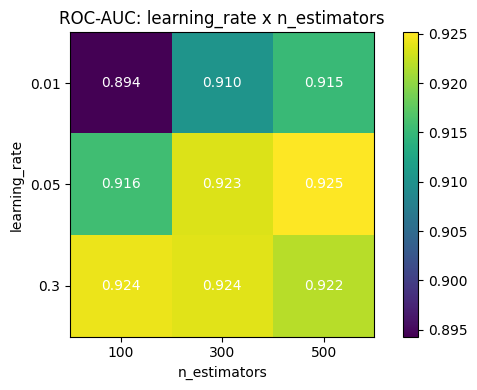

In [10]:
plt.figure(figsize=(6, 4))
im = plt.imshow(grid, cmap='viridis')
plt.xticks(range(len(n_ests)), n_ests); plt.yticks(range(len(lrs)), lrs)
plt.xlabel('n_estimators'); plt.ylabel('learning_rate')
plt.title('ROC-AUC: learning_rate x n_estimators')
for i in range(len(lrs)):
    for j in range(len(n_ests)):
        plt.text(j, i, f'{grid[i,j]:.3f}', ha='center', va='center', color='white')
plt.colorbar(im); plt.tight_layout()
plt.savefig(str(DATA_DIR.parent / 'reports' / 'lr_vs_nestimators.png'), dpi=120); plt.show()

## 8. So sánh Bagging (Random Forest) vs Boosting vs AdaBoost

In [11]:
models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'GradientBoosting': gb,
    'AdaBoost': AdaBoostClassifier(n_estimators=300, random_state=42),
}
comp_rows = []
for name, model in models.items():
    pipe = make_pipe(model)
    t0 = time.time(); pipe.fit(X_train, y_train); dt = time.time() - t0
    p = pipe.predict_proba(X_test)[:, 1]
    comp_rows.append({'model': name,
                       'pr_auc': average_precision_score(y_test, p),
                       'roc_auc': roc_auc_score(y_test, p),
                       'train_time_s': round(dt, 1)})
comp_df = pd.DataFrame(comp_rows)
comp_df.to_csv(str(DATA_DIR.parent / 'reports' / 'model_comparison.csv'), index=False)
comp_df

,model,pr_auc,roc_auc,train_time_s
0,RandomForest,0.743440,0.893914,57.3
1,GradientBoosting,0.819922,0.924722,9.4
2,AdaBoost,0.787272,0.912086,3.8


## 9. GradientBoosting vs HistGradientBoosting (tốc độ)

In [12]:
pre_dense = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols),
])
hgb = HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05,
                                      early_stopping=True, random_state=42)
hgb_pipe = Pipeline([('pre', pre_dense), ('clf', hgb)])
t0 = time.time(); hgb_pipe.fit(X_train, y_train); hgb_time = time.time() - t0
p_hgb = hgb_pipe.predict_proba(X_test)[:, 1]
print(f'GradientBoosting: {gb_time:.1f}s | HistGradientBoosting: {hgb_time:.1f}s '
      f'(nhanh hơn {gb_time/hgb_time:.1f}x)')
print(f'ROC-AUC HGB = {roc_auc_score(y_test, p_hgb):.3f}')

GradientBoosting: 9.4s | HistGradientBoosting: 4.3s (nhanh hơn 2.2x)
ROC-AUC HGB = 0.927


## 10. ⚖️ Kiểm tra thiên lệch theo `sex` và `race`
> Dữ liệu điều tra dân số Mỹ 1994 chứa định kiến lịch sử. Model có thể **học và khuếch đại** chênh lệch này. Không dùng cho quyết định thật về con người.

In [13]:
pred = gb_pipe.predict(X_test)
bias_rows = []
for group_col in ['sex', 'race']:
    for g in X_test[group_col].unique():
        mask = X_test[group_col] == g
        if mask.sum() < 20:
            continue
        bias_rows.append({
            'group_col': group_col, 'group': g, 'n': int(mask.sum()),
            'positive_rate_true': round(y_test[mask].mean(), 3),
            'positive_rate_pred': round(pred[mask].mean(), 3),
            'accuracy': round(accuracy_score(y_test[mask], pred[mask]), 3),
        })
bias_df = pd.DataFrame(bias_rows)
bias_df.to_csv(str(DATA_DIR.parent / 'reports' / 'bias_by_group.csv'), index=False)
bias_df

,group_col,group,n,positive_rate_true,positive_rate_pred,accuracy
0,sex,Male,10860,0.300,0.251,0.841
1,sex,Female,5421,0.109,0.079,0.938
2,race,Black,1561,0.115,0.081,0.931
3,race,White,13946,0.250,0.207,0.866
4,race,Asian-Pac-Islander,480,0.277,0.240,0.858
5,race,Other,135,0.185,0.089,0.889
6,race,Amer-Indian-Eskimo,159,0.119,0.094,0.899


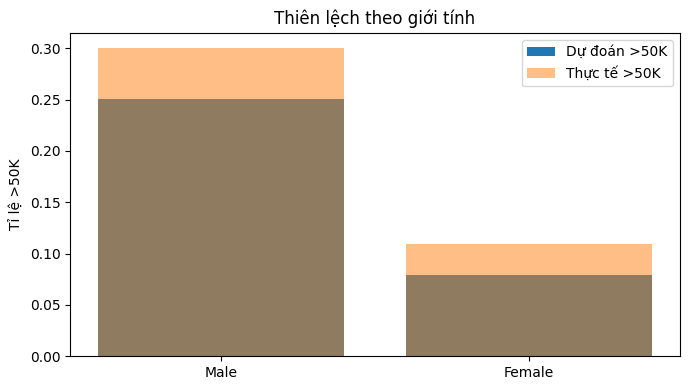

In [14]:
plt.figure(figsize=(7, 4))
sub = bias_df[bias_df.group_col == 'sex']
plt.bar(sub['group'], sub['positive_rate_pred'], label='Dự đoán >50K')
plt.bar(sub['group'], sub['positive_rate_true'], alpha=0.5, label='Thực tế >50K')
plt.ylabel('Tỉ lệ >50K'); plt.title('Thiên lệch theo giới tính'); plt.legend()
plt.tight_layout(); plt.savefig(str(DATA_DIR.parent / 'reports' / 'bias_by_group.png'), dpi=120); plt.show()

## 11. Lưu model & tổng kết

In [15]:
MODEL_PATH = DATA_DIR.parent / 'models' / 'gb_pipeline.joblib'
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(gb_pipe, MODEL_PATH)
print('Đã lưu model tại', MODEL_PATH.resolve())
pd.DataFrame(results).T

Đã lưu model tại /home/claude/TT-07-GradientBoosting/models/gb_pipeline.joblib


,pr_auc,roc_auc
Dummy,0.236226,0.500000
DecisionTree,0.723033,0.895448
GradientBoosting,0.819922,0.924722
